In [2]:
import numpy as np
import matplotlib.pyplot as plt

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step sizes: h[i] is x[i+1] - x[i]
    
    # Initialize the tridiagonal matrix coefficients for (n-2) internal equations
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):

        A[i - 1] = h[i - 1] #Subdiagonal
        B[i - 1] = 2 * (h[i - 1] + h[i]) #Main diagonal
        C[i - 1] = h[i] #Superdiagonal
        D[i - 1] = 6 * (((y[i + 1] - y[i]) / h[i]) - (y[i] - y[i - 1]) / (h[i - 1])) #Right-hand side vector

    return A, B, C, D

def thomas_algorithm(a, b, c, d):
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def evaluate_spline(x_data, y_data, M, x_query):
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

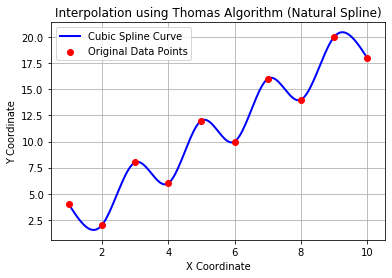

In [4]:
#Known Data
x_data = np.array([1,2,3,4,5,6,7,8,9,10])
y_data = np.array([4,2,8,6,12,10,16,14,20,18])
#Setup and Solve System
a, b, c, d = setup_tridiagonal_matrix(x_data, y_data)
M_internal = thomas_algorithm(a, b, c, d)

#Boundary Conditions
M = np.zeros(len(x_data))
M[1:-1] = M_internal

#Plotting
x_plot = np.linspace(x_data[0], x_data[-1], 200)
y_plot = evaluate_spline(x_data, y_data, M, x_plot)

#Graphing
plt.plot(x_plot, y_plot, label='Cubic Spline Curve', color='blue', linewidth=2)
plt.scatter(x_data, y_data, color='red', label='Original Data Points', zorder=5)
plt.title("Interpolation using Thomas Algorithm (Natural Spline)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.grid(True)
plt.show()

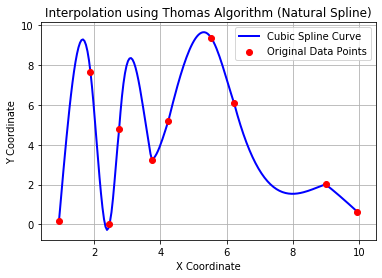

In [6]:
#Random Data
x_data = np.sort(np.random.rand(10) * 10)
y_data = np.random.rand(10) * 10

#Setup and Solve System
a, b, c, d = setup_tridiagonal_matrix(x_data, y_data)
M_internal = thomas_algorithm(a, b, c, d)

#Boundary Conditions
M = np.zeros(len(x_data))
M[1:-1] = M_internal

#Plotting
x_plot = np.linspace(x_data[0], x_data[-1], 200)
y_plot = evaluate_spline(x_data, y_data, M, x_plot)

#Graphing
plt.plot(x_plot, y_plot, label='Cubic Spline Curve', color='blue', linewidth=2)
plt.scatter(x_data, y_data, color='red', label='Original Data Points', zorder=5)
plt.title("Interpolation using Thomas Algorithm (Natural Spline)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.grid(True)
plt.show()